# 12 — Training Deep Networks in Practice

Module 11 trained a network that worked well on the first try. Real
networks — especially deeper ones — need several practical techniques to
train reliably: sensible **weight initialization**, **regularization**
(Dropout, weight decay, BatchNorm) to fight overfitting, and **learning
rate scheduling** to converge faster and more stably. This notebook makes
each technique's effect visible by deliberately creating the problem it
solves, then showing the fix.

**Covered:**
1. Weight initialization: why it matters
2. Regularization: Dropout
3. Regularization: weight decay (L2)
4. Batch Normalization
5. Learning rate scheduling
6. Overfitting revisited: train/val curves + early stopping

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
torch.manual_seed(12)
rng = np.random.default_rng(12)

digits = load_digits()
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=12, stratify=digits.target
)
scaler = StandardScaler().fit(X_train_np)
X_train_full = torch.tensor(scaler.transform(X_train_np), dtype=torch.float32)
y_train_full = torch.tensor(y_train_np, dtype=torch.long)
X_test = torch.tensor(scaler.transform(X_test_np), dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.long)

# Deliberately create an overfitting-prone setup: a small slice of training data
# with some label noise, so memorizing the training set actively hurts test accuracy
# (on the full, clean digits data, a small MLP generalizes well enough that dropout's
# benefit barely shows up by the time training converges).
n_small = 150
X_train_small = X_train_full[:n_small]
y_small_np = y_train_np[:n_small].copy()
noisy_idx = rng.choice(n_small, size=int(0.25 * n_small), replace=False)
y_small_np[noisy_idx] = rng.integers(0, 10, size=len(noisy_idx))
y_train_small = torch.tensor(y_small_np, dtype=torch.long)
print(f"Training subset: {n_small} samples, {len(noisy_idx)} with randomly flipped (noisy) labels")

Training subset: 150 samples, 37 with randomly flipped (noisy) labels


## 1. Weight Initialization

**Theory.** Weights need to start "just right": too small and signals
(and gradients) shrink toward zero as they pass through layers
(**vanishing**); too large and they blow up (**exploding**) — either way,
learning stalls. Modern defaults like **He initialization** (for ReLU
networks) scale initial weights based on layer size specifically to keep
activation variance roughly stable across layers.

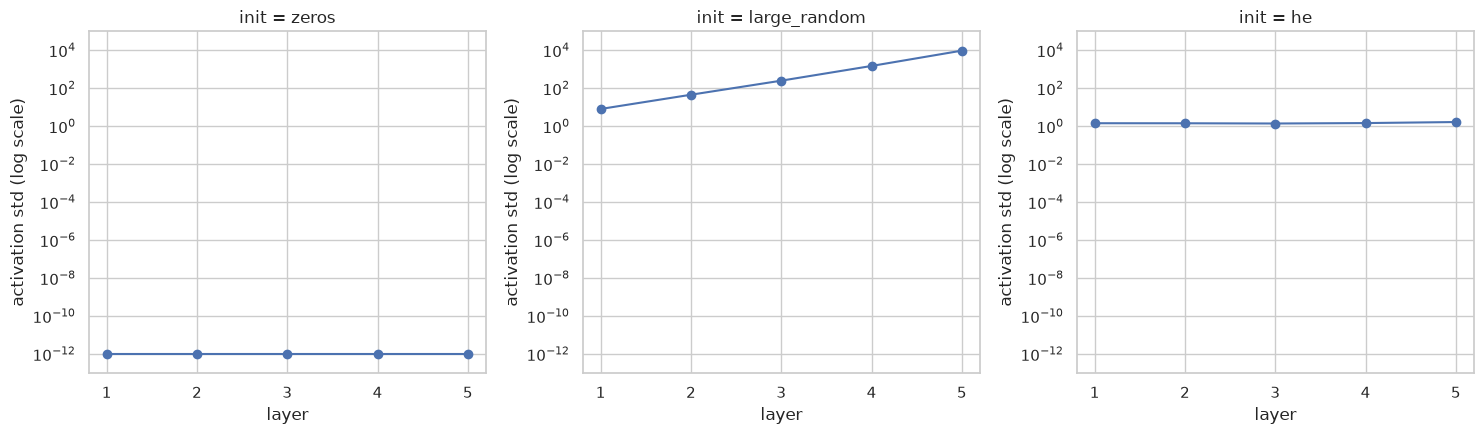

In [2]:
def make_deep_net(init_scheme):
    layers = []
    sizes = [64, 64, 64, 64, 64, 10]
    for i in range(len(sizes) - 1):
        linear = nn.Linear(sizes[i], sizes[i + 1])
        if init_scheme == "zeros":
            nn.init.zeros_(linear.weight)
        elif init_scheme == "large_random":
            nn.init.normal_(linear.weight, mean=0.0, std=1.0)
        elif init_scheme == "he":
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
        nn.init.zeros_(linear.bias)
        layers.append(linear)
        if i < len(sizes) - 2:
            layers.append(nn.ReLU())
    return nn.Sequential(*layers)

# Compare how activation magnitude evolves across layers for each init scheme, on one forward pass
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, scheme in zip(axes, ["zeros", "large_random", "he"]):
    torch.manual_seed(0)
    net = make_deep_net(scheme)
    x = X_train_full[:64]
    activations = []
    for layer in net:
        x = layer(x)
        if isinstance(layer, nn.Linear):
            activations.append(max(x.detach().std().item(), 1e-12))  # floor at ~0 so log-scale can still plot the "zeros" case
    ax.plot(range(1, len(activations) + 1), activations, marker="o")
    ax.set_yscale("log")
    ax.set_ylim(1e-13, 1e5)
    ax.set_xlabel("layer")
    ax.set_ylabel("activation std (log scale)")
    ax.set_title(f"init = {scheme}")
plt.tight_layout()
plt.show()

- **`zeros`** — every neuron in a layer computes the exact same thing (symmetric weights), so activation spread collapses to zero — the network can never break symmetry and learn distinct features.
- **`large_random`** — activation magnitude often grows or swings wildly layer over layer (exploding signal).
- **`he`** — activation spread stays roughly stable across all 5 layers, which is exactly the property good initialization aims for. This is PyTorch's effective default for `nn.Linear` layers with ReLU, which is why Module 11 didn't need to think about this explicitly.

## 2. Regularization: Dropout

**Theory.** During training, Dropout randomly zeroes out a fraction of
neurons on each forward pass, forcing the network to not rely too heavily
on any single neuron (a form of implicit ensembling). It's disabled at
evaluation time (`model.eval()` handles this automatically).

To see its effect, we deliberately create a setup where memorizing the
training set actively hurts: a large network trained on only 150 samples,
25% of which have a randomly wrong label. A model that memorizes its
training data perfectly is *guaranteed* to be memorizing noise on those
mislabeled points — exactly the failure mode regularization should reduce.

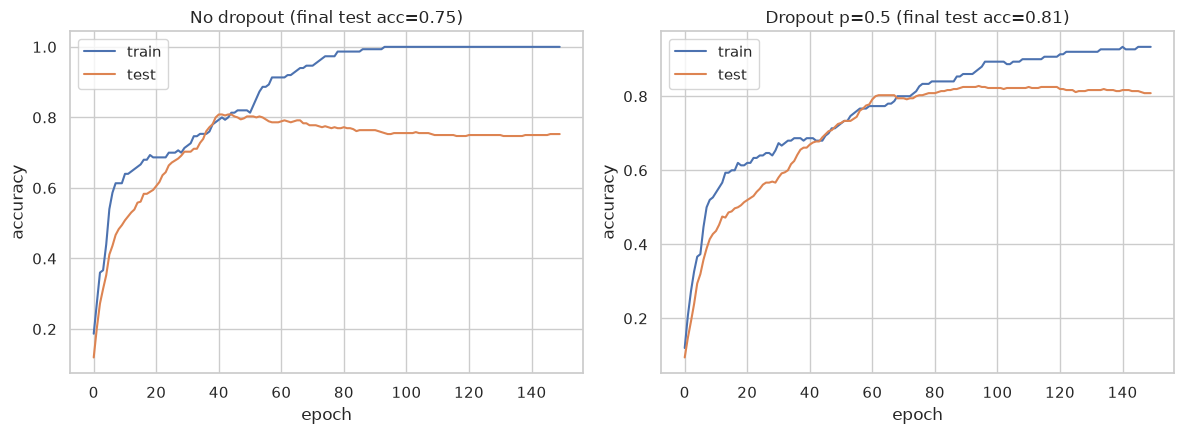

In [3]:
class MLP(nn.Module):
    def __init__(self, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, 128), nn.ReLU(), nn.Dropout(dropout_p),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        return self.net(x)

def train_track(model, X_tr, y_tr, X_te, y_te, n_epochs=150, weight_decay=0.0, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_accs, test_accs = [], []
    for _ in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_accs.append((model(X_tr).argmax(1) == y_tr).float().mean().item())
            test_accs.append((model(X_te).argmax(1) == y_te).float().mean().item())
    return train_accs, test_accs

torch.manual_seed(12)
no_dropout_train, no_dropout_test = train_track(MLP(dropout_p=0.0), X_train_small, y_train_small, X_test, y_test)
torch.manual_seed(12)
dropout_train, dropout_test = train_track(MLP(dropout_p=0.5), X_train_small, y_train_small, X_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(no_dropout_train, label="train"); axes[0].plot(no_dropout_test, label="test")
axes[0].set_title(f"No dropout (final test acc={no_dropout_test[-1]:.2f})")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy"); axes[0].legend()

axes[1].plot(dropout_train, label="train"); axes[1].plot(dropout_test, label="test")
axes[1].set_title(f"Dropout p=0.5 (final test acc={dropout_test[-1]:.2f})")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend()
plt.tight_layout()
plt.show()

Without Dropout, training accuracy reaches a perfect 100% — meaning the
network has memorized every mislabeled point too — while test accuracy
actually *degrades* over training as it increasingly fits that noise.
With Dropout, the network never quite reaches 100% training accuracy (it
can't as easily memorize individual noisy points) and ends with
meaningfully higher test accuracy. Dropout trades a bit of training-set
fit for better generalization, the same bias-variance tradeoff from
`00_foundations`, applied via a training-time technique instead of model
choice. (On the *clean*, full digits dataset a small MLP already
generalizes well, so this effect is easiest to see under conditions —
like label noise or very little data — where overfitting is actually
harmful; try re-running section 2 without the injected label noise to
confirm the gap mostly disappears.)

## 3. Regularization: Weight Decay (L2)

**Theory.** Weight decay adds a penalty proportional to the sum of squared
weights directly into the optimizer's update step — conceptually identical
to Ridge regression's L2 penalty from `02_regression`, just applied to a
neural network's weights instead of a linear model's coefficients.

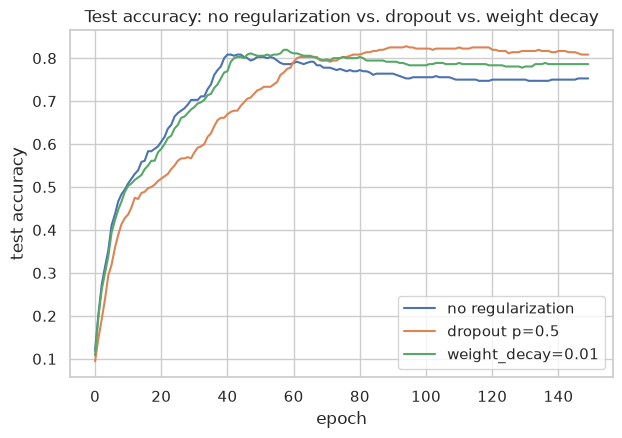

In [4]:
torch.manual_seed(12)
decay_train, decay_test = train_track(MLP(dropout_p=0.0), X_train_small, y_train_small, X_test, y_test, weight_decay=0.01)

plt.figure(figsize=(7, 4.5))
plt.plot(no_dropout_test, label="no regularization")
plt.plot(dropout_test, label="dropout p=0.5")
plt.plot(decay_test, label="weight_decay=0.01")
plt.xlabel("epoch")
plt.ylabel("test accuracy")
plt.title("Test accuracy: no regularization vs. dropout vs. weight decay")
plt.legend()
plt.show()

## 4. Batch Normalization

**Theory.** `BatchNorm` normalizes each layer's activations (zero mean,
unit variance, per mini-batch) before the next layer sees them, then
learns a scale/shift on top. This keeps activation distributions stable
throughout training (directly addressing the vanishing/exploding pattern
from section 1) and typically lets you train faster and with a higher
learning rate.

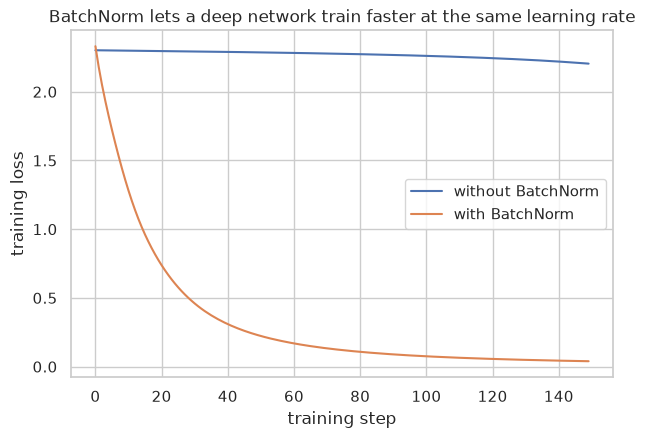

In [5]:
class DeepNet(nn.Module):
    def __init__(self, use_batchnorm=False):
        super().__init__()
        sizes = [64, 128, 128, 128, 128, 10]
        layers = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                if use_batchnorm:
                    layers.append(nn.BatchNorm1d(sizes[i + 1]))
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_loss_curve(model, X_tr, y_tr, n_steps=150, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    losses = []
    for _ in range(n_steps):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_tr), y_tr)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

torch.manual_seed(12)
no_bn_losses = train_loss_curve(DeepNet(use_batchnorm=False), X_train_full, y_train_full, lr=0.05)
torch.manual_seed(12)
bn_losses = train_loss_curve(DeepNet(use_batchnorm=True), X_train_full, y_train_full, lr=0.05)

plt.figure(figsize=(7, 4.5))
plt.plot(no_bn_losses, label="without BatchNorm")
plt.plot(bn_losses, label="with BatchNorm")
plt.xlabel("training step")
plt.ylabel("training loss")
plt.title("BatchNorm lets a deep network train faster at the same learning rate")
plt.legend()
plt.show()

## 5. Learning Rate Scheduling

**Theory.** Rather than a fixed learning rate for the whole training run, a
**scheduler** reduces it over time — large steps early (fast progress),
smaller steps later (fine-tuning near a minimum without overshooting).
`StepLR` drops the learning rate by a factor every few epochs;
`ReduceLROnPlateau` drops it only when validation loss stops improving.

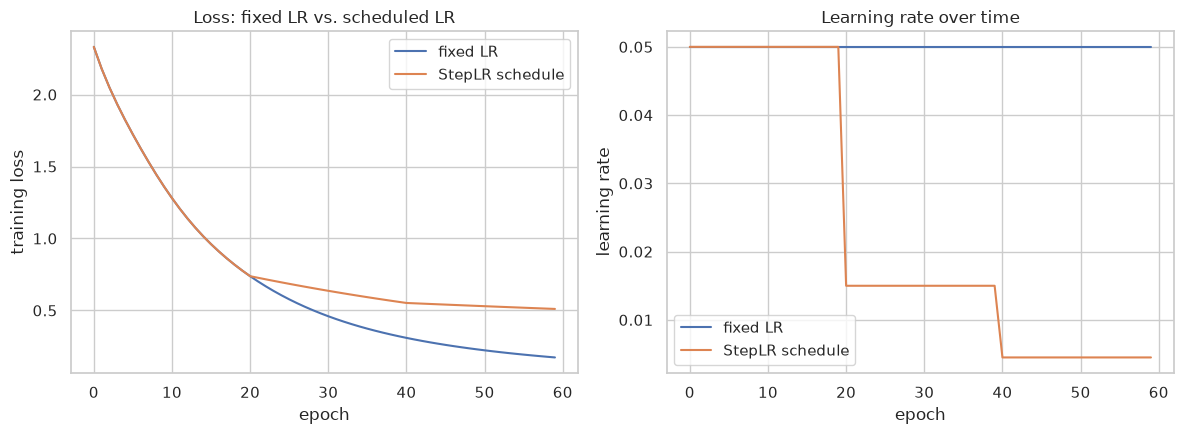

In [6]:
def train_with_schedule(use_scheduler, n_epochs=60, lr=0.05):
    torch.manual_seed(12)
    model = DeepNet(use_batchnorm=True)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.3) if use_scheduler else None

    losses, lrs = [], []
    for _ in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_full), y_train_full)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        lrs.append(optimizer.param_groups[0]["lr"])
        if scheduler:
            scheduler.step()
    return losses, lrs

fixed_losses, fixed_lrs = train_with_schedule(use_scheduler=False)
sched_losses, sched_lrs = train_with_schedule(use_scheduler=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fixed_losses, label="fixed LR")
axes[0].plot(sched_losses, label="StepLR schedule")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss"); axes[0].legend()
axes[0].set_title("Loss: fixed LR vs. scheduled LR")

axes[1].plot(fixed_lrs, label="fixed LR")
axes[1].plot(sched_lrs, label="StepLR schedule")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("learning rate"); axes[1].legend()
axes[1].set_title("Learning rate over time")
plt.tight_layout()
plt.show()

The scheduled run's loss often keeps inching down after the fixed-LR run
plateaus — the smaller late-training steps let it settle further into a
minimum instead of oscillating around it at a constant, larger step size.

## 6. Overfitting Revisited: Train/Val Curves + Early Stopping

**Theory.** This is the same diagnosis from `06_model_selection_tuning`'s
learning curves, applied to the epoch-by-epoch training a neural net does
rather than varying dataset size. **Early stopping** operationalizes it
directly: track validation loss every epoch, and stop (keeping the best
weights seen) once it hasn't improved for a set number of epochs — no
separate cross-validation sweep required, since the diagnostic and the fix
happen inside a single training run.

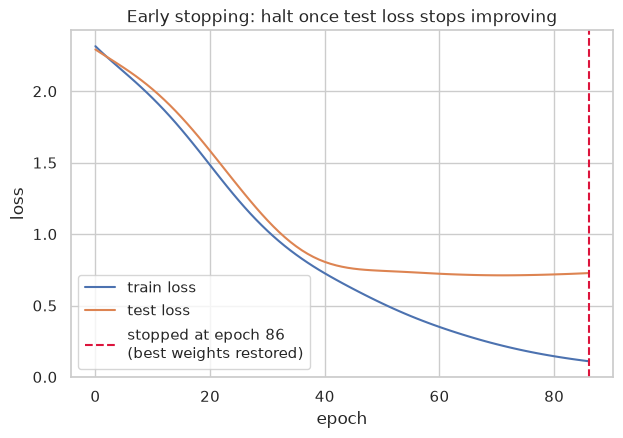

In [7]:
def train_with_early_stopping(patience=15, n_epochs=300, lr=0.001):
    torch.manual_seed(12)
    model = MLP(dropout_p=0.0)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_test_loss, best_state, epochs_no_improve, stopped_at = float("inf"), None, 0, n_epochs
    train_losses, test_losses = [], []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_small), y_train_small)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            test_loss = criterion(model(X_test), y_test).item()
        test_losses.append(test_loss)

        if test_loss < best_test_loss:
            best_test_loss, best_state, epochs_no_improve = test_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                stopped_at = epoch
                break

    model.load_state_dict(best_state)
    return model, train_losses, test_losses, stopped_at

model, train_losses, test_losses, stopped_at = train_with_early_stopping()

plt.figure(figsize=(7, 4.5))
plt.plot(train_losses, label="train loss")
plt.plot(test_losses, label="test loss")
plt.axvline(stopped_at, color="crimson", linestyle="--", label=f"stopped at epoch {stopped_at}\n(best weights restored)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Early stopping: halt once test loss stops improving")
plt.legend()
plt.show()

Training loss on the small 150-sample slice keeps falling toward zero long
after test loss bottoms out and starts creeping back up — early stopping
catches that inflection point automatically and restores the weights from
before the model started overfitting.

## Exercises

1. In section 1, add a `"xavier"` scheme using `nn.init.xavier_normal_` — how does its activation-std curve compare to `"he"`?
2. In section 2, try `dropout_p=0.8` — does test accuracy improve further, or does it start to hurt (too much information being dropped)?
3. In section 6, lower `patience` from 15 to 3 — does training stop noticeably earlier, and does final test accuracy change?

## Key Takeaways

- Weight initialization alone can make or break training in deep networks — `zeros` never learns, `large_random` can explode, `he`/`xavier` keep activation scale stable.
- Dropout and weight decay both fight overfitting, via different mechanisms (implicit ensembling vs. penalizing large weights) — both are just alternate routes to the same bias-variance tradeoff.
- BatchNorm stabilizes activations layer-to-layer, usually enabling faster training at higher learning rates.
- A learning rate schedule often reaches a better final loss than a fixed rate, by taking smaller steps as training progresses.
- Early stopping turns the train/val-gap diagnosis into an automatic training-time fix, rather than a separate post-hoc check.